<a href="https://colab.research.google.com/github/amina489/mathematical-modeling/blob/main/BloodMNIST_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Installing required packages

!pip -q install medmnist scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.6 MB/s eta 0:00:00


In [ ]:
# Step 2: Importing libraries and configuring the project

import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import medmnist
from medmnist import INFO

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")

Device: cuda


In [ ]:
# Step 3: Loading the BloodMNIST dataset

data_flag = "bloodmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

print(f"Dataset: {data_flag}")
print(f"Classes: {len(info['label'])}")
print(f"Class names: {list(info['label'].values())}")
print(f"Training images: {info['n_samples']['train']}")
print(f"Validation images: {info['n_samples']['val']}")
print(f"Test images: {info['n_samples']['test']}")

Dataset: bloodmnist
Classes: 8
Class names: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
Training images: 11959
Validation images: 1712
Test images: 3421


In [ ]:
# Step 4: Preparing images and data loaders

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = DataClass(
    split="train",
    transform=train_transform,
    download=True,
    as_rgb=True,
    size=224
)

val_dataset = DataClass(
    split="val",
    transform=eval_transform,
    download=True,
    as_rgb=True,
    size=224
)

test_dataset = DataClass(
    split="test",
    transform=eval_transform,
    download=True,
    as_rgb=True,
    size=224
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

100%|██████████| 1.54G/1.54G [25:32<00:00, 1.01MB/s]


Train batches: 187
Validation batches: 27
Test batches: 54


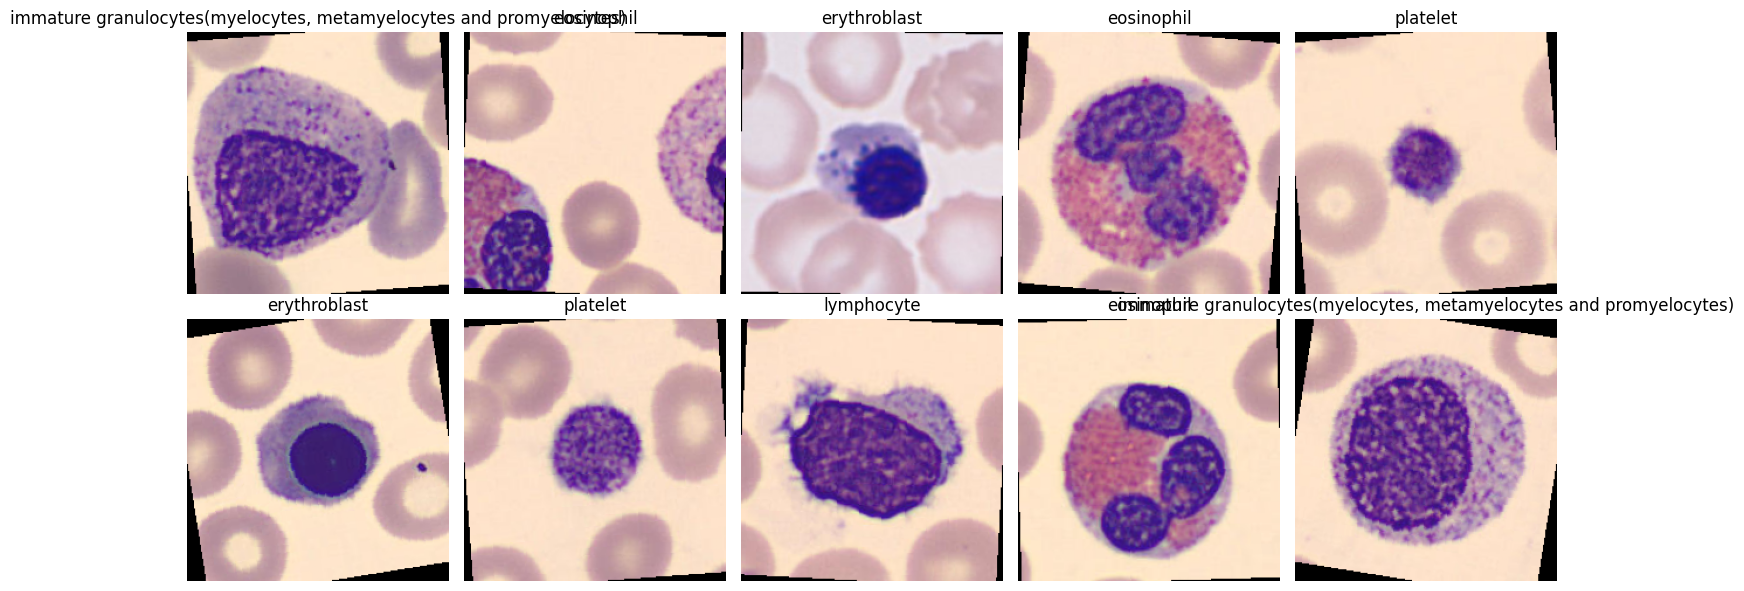

In [ ]:
# Step 5: Visualizing BloodMNIST samples

class_names = list(info["label"].values())

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes.flat):
    image = images[i].cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Loading and configuring the ResNet-18 model

model = resnet18(weights=weights)

num_features = model.fc.in_features
num_classes = len(class_names)

model.fc = nn.Linear(num_features, num_classes)
model = model.to(device)

print(f"Number of output classes: {num_classes}")
print(f"Model device: {device}")

Number of output classes: 8
Model device: cuda


In [ ]:
# Step 7: Configuring the training process

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0003,
    weight_decay=0.0001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

epochs = 5

print(f"Epochs: {epochs}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

Epochs: 5
Learning rate: 0.0003


In [ ]:
# Step 8: Training and validating the model

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.squeeze().long().to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / train_total
    train_accuracy = train_correct / train_total

    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.squeeze().long().to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / val_total
    val_accuracy = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    scheduler.step(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "best_bloodmnist_resnet18.pth")

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epoch 1/5 | Train Loss: 0.1453 | Train Acc: 0.9530 | Val Loss: 0.2113 | Val Acc: 0.9305
Epoch 2/5 | Train Loss: 0.0659 | Train Acc: 0.9781 | Val Loss: 0.0646 | Val Acc: 0.9825
Epoch 3/5 | Train Loss: 0.0500 | Train Acc: 0.9818 | Val Loss: 0.0399 | Val Acc: 0.9854
Epoch 4/5 | Train Loss: 0.0404 | Train Acc: 0.9860 | Val Loss: 0.0698 | Val Acc: 0.9761
Epoch 5/5 | Train Loss: 0.0362 | Train Acc: 0.9883 | Val Loss: 0.0426 | Val Acc: 0.9848
Best validation accuracy: 0.9854


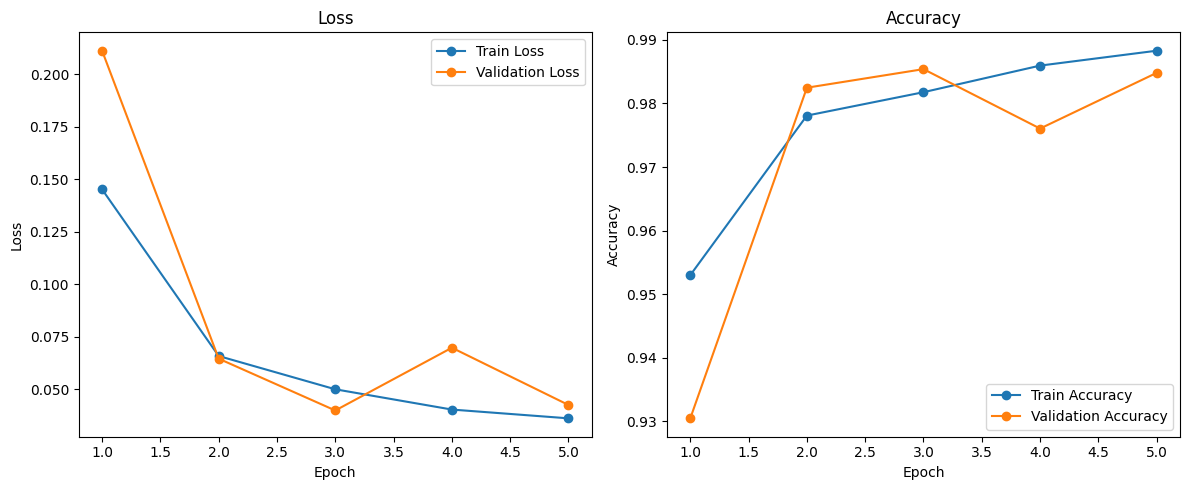

In [ ]:
# Step 9: Plotting training performance

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs_range, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Step 10: Evaluating the best model on the test set

model.load_state_dict(
    torch.load("best_bloodmnist_resnet18.pth", map_location=device)
)

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.squeeze().long().to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = accuracy_score(all_labels, all_predictions)
test_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)
test_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)
test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall: {test_recall:.4f}")
print(f"Macro F1: {test_f1:.4f}")

Test Accuracy: 0.9810
Macro Precision: 0.9821
Macro Recall: 0.9795
Macro F1: 0.9806


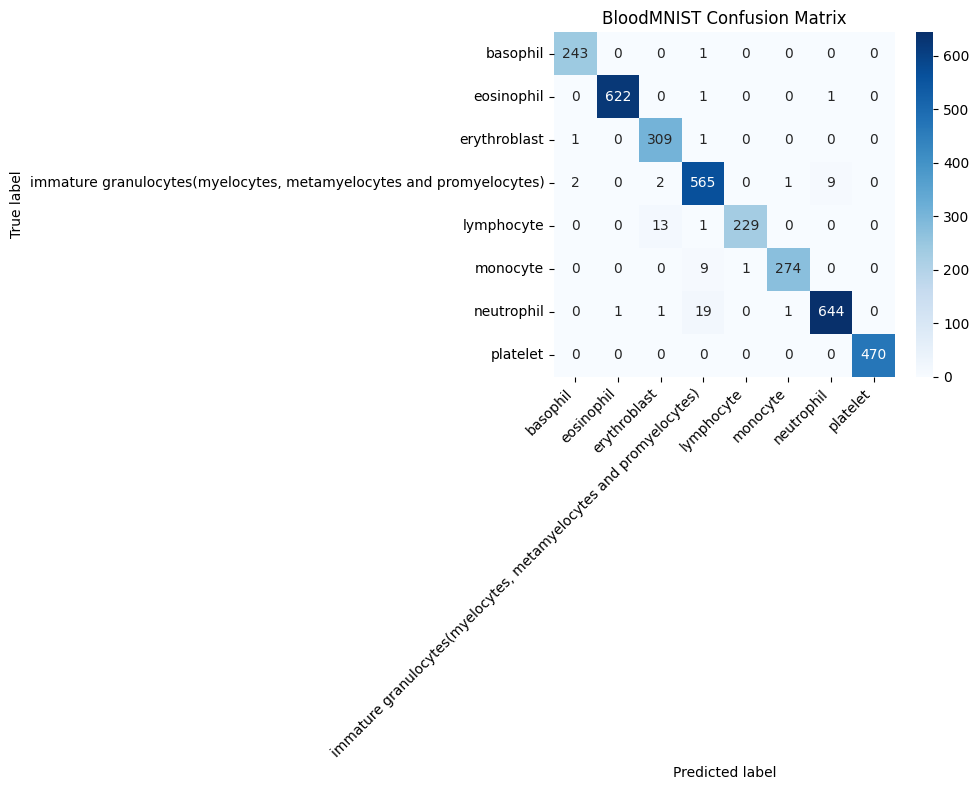

                                                                     precision    recall  f1-score   support

                                                           basophil       0.99      1.00      0.99       244
                                                         eosinophil       1.00      1.00      1.00       624
                                                       erythroblast       0.95      0.99      0.97       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.95      0.98      0.96       579
                                                         lymphocyte       1.00      0.94      0.97       243
                                                           monocyte       0.99      0.96      0.98       284
                                                         neutrophil       0.98      0.97      0.98       666
                                                           platelet       1.00      1.00      1.00       470

                 

In [ ]:
# Step 11: Analyzing class-level performance

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BloodMNIST Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)

In [ ]:
# Step 12: Creating interactive prediction and exporting the model

from google.colab import files
from PIL import Image
from IPython.display import display

uploaded = files.upload()

if uploaded:
    file_name = next(iter(uploaded))
    image = Image.open(file_name).convert("RGB")

    display(image.resize((224, 224)))

    input_tensor = eval_transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        probabilities = torch.softmax(model(input_tensor), dim=1)
        confidence, predicted_class = probabilities.max(dim=1)

    predicted_name = class_names[predicted_class.item()]
    confidence_value = confidence.item() * 100

    print(f"Predicted class: {predicted_name}")
    print(f"Confidence: {confidence_value:.2f}%")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names
    },
    "bloodmnist_resnet18_model.pth"
)

print("Model saved as bloodmnist_resnet18_model.pth")